# The macro environment — the stage the premium stands on

The premium is not a company story. It sits inside a policy, flow and funding environment that
can move it for reasons that have nothing to do with SK Hynix's earnings. This notebook presents
that environment, **describes it, and does not call it** — there is no forecast here.

Panels: **P0a** (the stage) and **P0b** (the currents), both exported with the client pack.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme
from scripts.export_client_pack import panels
theme.apply()
PANELS = dict(panels())

## 1. Regulatory state — the constraints that shape every short leg

Three facts from the repo's event register, each with its premium relevance in one line.

- **Short selling resumed 2025-03-31.** The ban imposed in November 2023 was fully lifted, so
  all listed stocks are shortable. *Relevance: without this the short leg does not exist at all.*
- **Single-stock 2× ETF listings suspended 2026-07-16**, deposit requirement raised, accelerated
  to **2026-07-31**. Eligibility rules admit only two names. *Relevance: concentrated in this
  underlying, so it is a flow event for this pair specifically.*
- **Eurex–KRX link terminated 2025-06-06**; KRX has run its own night session since
  **2025-06-09**. *Relevance: the overnight hedging route changed, and the synthetic
  contemporaneous premium depends on which session is available.*

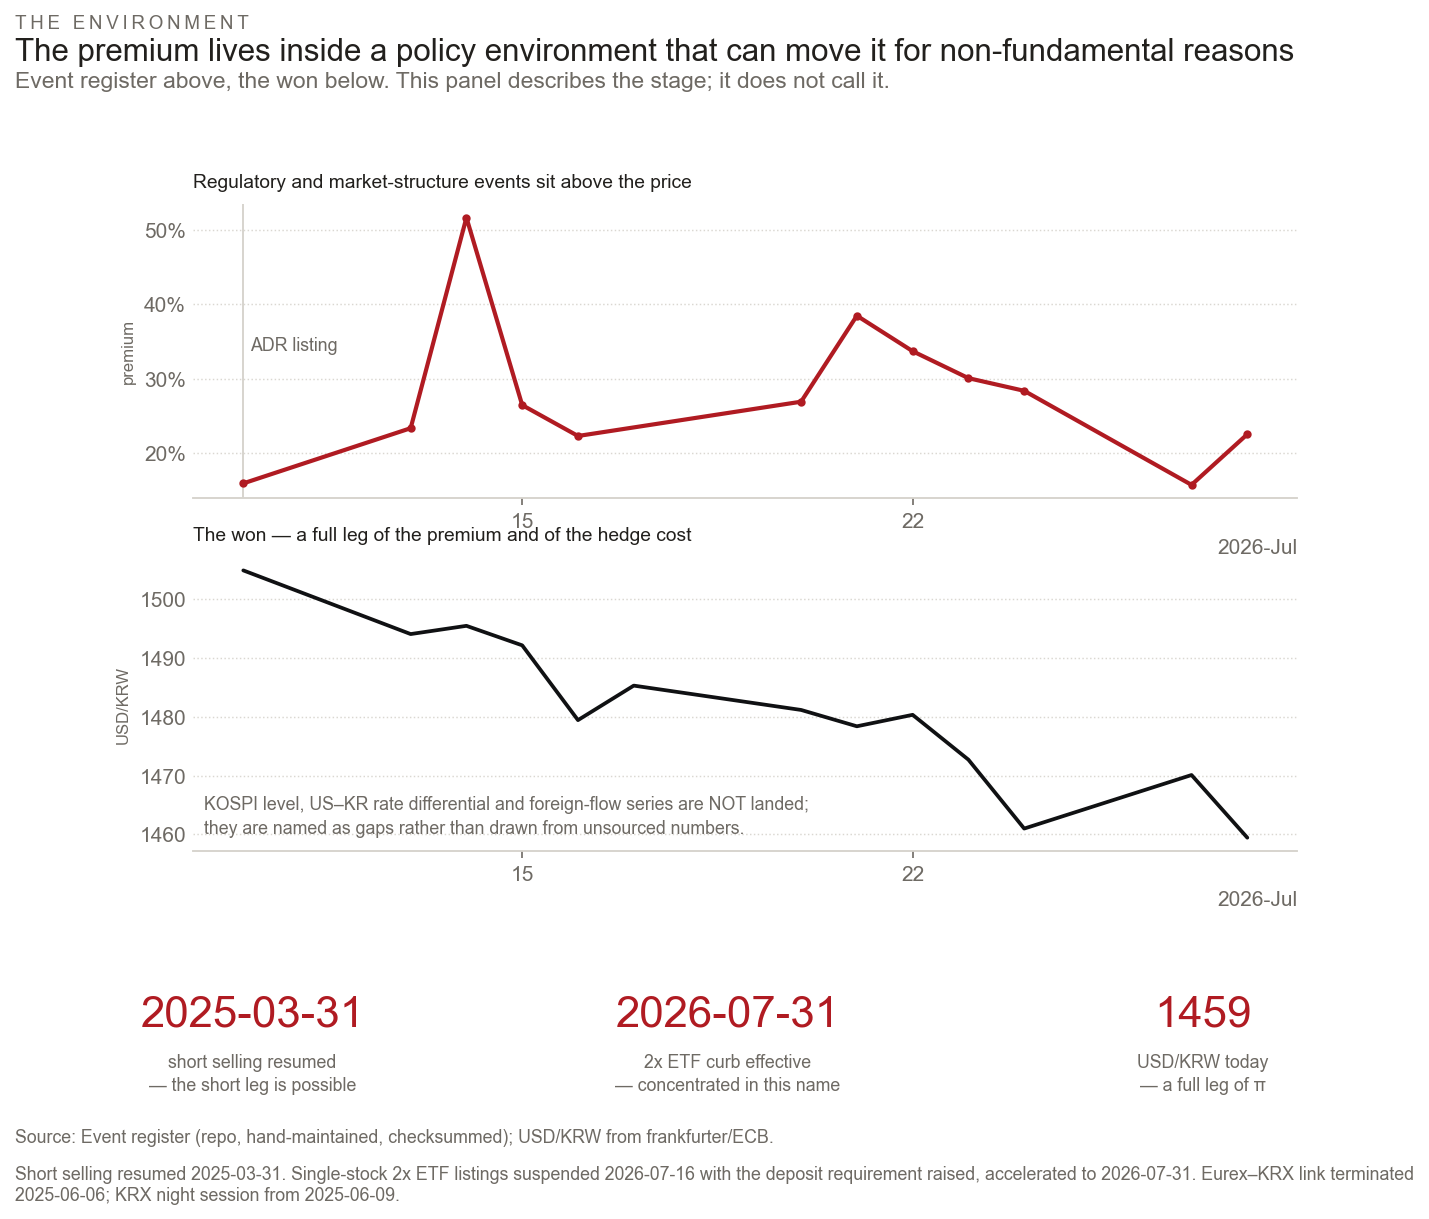

In [2]:
fig, _ = PANELS["P0a_the_stage"]()
fig;

**In plain terms**

- This gap does not float in space. Korean rules on short selling, a leveraged-ETF curb landing
  this month, and the won all move it.
- None of those are about whether SK hynix is a good company. They can push the gap around on
  their own.
- Two dates to know cold: short selling came back in March 2025, and the ETF curb bites end of
  July.

## 2. The currents — index, currency, funding

Three series, three frequencies. The rate differential is presented **monthly** because its
Korea leg is monthly: interpolating an OECD series to daily for a context panel would
manufacture observations nobody published.

**FX is not context here — it is a leg.** π = P_ADR · FX / (n · P_local) − 1, so the won enters
the premium directly, and again through the hedge cost. That is why it appears on a macro panel
and in the hedge menu.

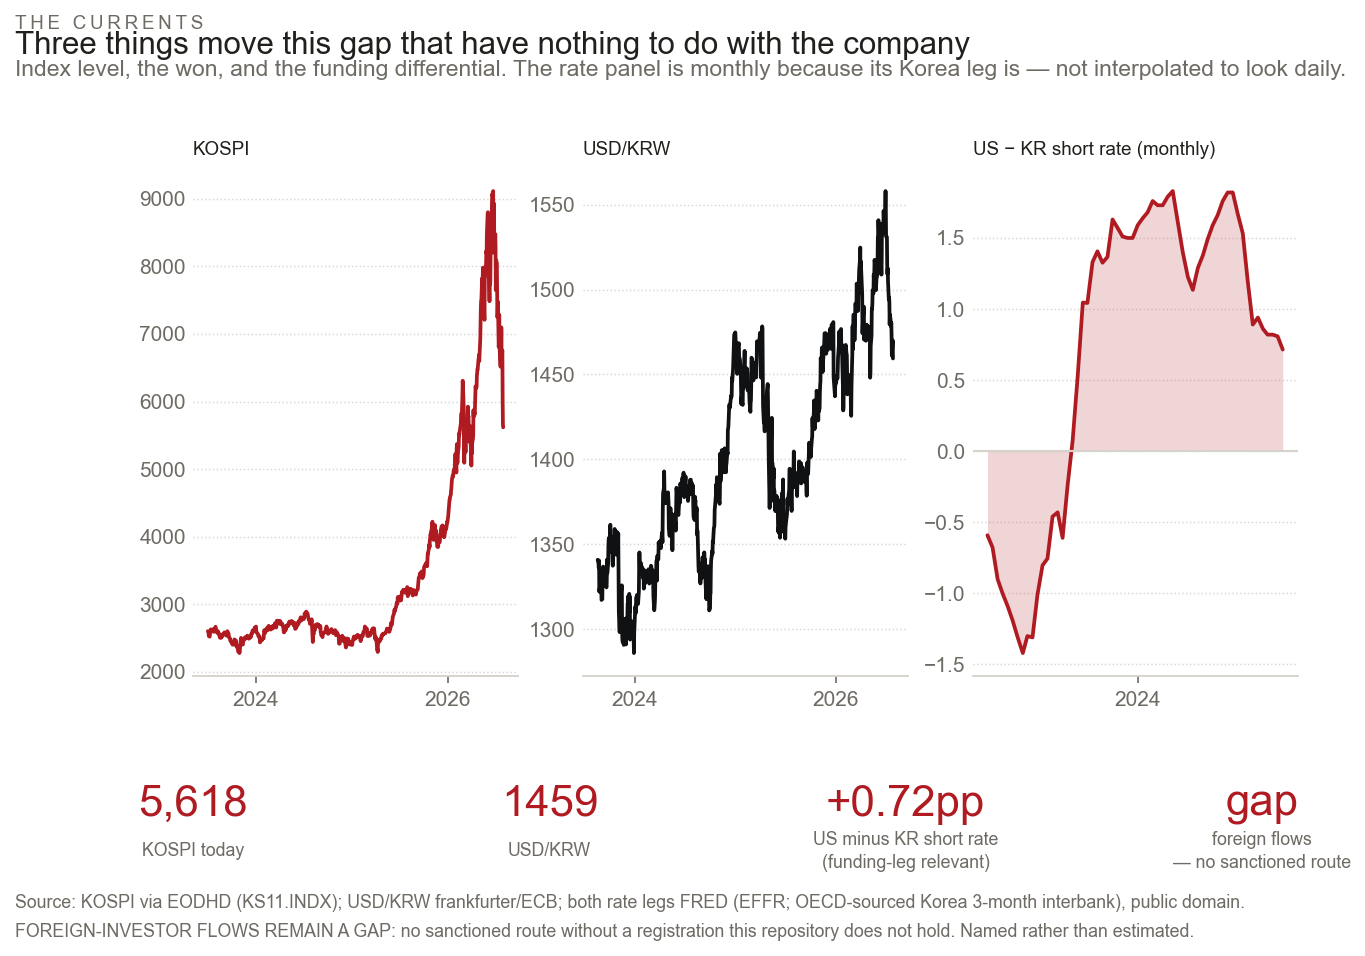

In [3]:
fig, _ = PANELS["P0b_the_currents"]()
fig;

**In plain terms**

- Three outside forces move this gap: the Korean market overall, the won, and the gap between US
  and Korean interest rates.
- None of them are about SK hynix. The rate one matters most to you, because it is what funding
  the position costs.
- One thing we still cannot show you is what foreign investors are doing month to month — there is
  no clean public feed for it, so we say so rather than guess.

## 3. What this layer cannot show

**Foreign-investor flows are a named gap.** No sanctioned route exists without a registration
this repository does not hold: no KRX Open API key is present, and the `data.go.kr` catalogue
route requires the same. The panel says so rather than estimating a direction.

Two series that *were* gaps closed this session, both through access already held — KOSPI via
EODHD's index symbology (`KS11.INDX`; `^KS11` and `KOSPI.INDX` both 404), and both rate legs
from FRED, which is public domain and the cleanest provenance in the repo.

**US backdrop, three sentences.** The US leg of the funding differential is EFFR, landed daily.
The demand side of the ADR bid is the AI-capex and HBM cycle, whose scheduled expression in this
repo is the Q2 earnings date already in the event register. This notebook does not model that
cycle and does not take a view on it.